In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from prophet import Prophet
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

plt.style.use("seaborn-v0_8")
plt.rcParams["figure.figsize"] = (14, 6)


In [2]:
train = pd.read_csv("../data/raw/train.csv")
features = pd.read_csv("../data/raw/features.csv")
stores = pd.read_csv("../data/raw/stores.csv")

df = train.merge(features, on=["Store", "Date", "IsHoliday"], how="left")
df = df.merge(stores, on="Store", how="left")

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")


In [3]:
for col in ["Temperature", "Fuel_Price", "CPI", "Unemployment"]:
    df[col].fillna(df[col].median(), inplace=True)


C:\Users\prana\AppData\Local\Temp\ipykernel_15040\4192736173.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\prana\AppData\Local\Temp\ipykernel_15040\4192736173.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For examp

In [4]:
STORE_ID = 1
DEPT_ID = 1

sales_df = df[
    (df["Store"] == STORE_ID) &
    (df["Dept"] == DEPT_ID)
][["Date", "Weekly_Sales", "Temperature", "Fuel_Price", "IsHoliday"]]


In [5]:
sales_df.columns = ["ds", "y", "temperature", "fuel_price", "is_holiday"]
sales_df.head()


,ds,y,temperature,fuel_price,is_holiday
0,2010-02-05,24924.50,42.31,2.572,False
1,2010-02-12,46039.49,38.51,2.548,True
2,2010-02-19,41595.55,39.93,2.514,False
3,2010-02-26,19403.54,46.63,2.561,False
4,2010-03-05,21827.90,46.50,2.625,False


In [6]:
train_size = int(len(sales_df) * 0.8)

train_df = sales_df.iloc[:train_size]
test_df = sales_df.iloc[train_size:]


In [7]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode="multiplicative"
)


In [8]:
model.add_regressor("temperature")
model.add_regressor("fuel_price")


In [9]:
model.fit(train_df)


21:14:19 - cmdstanpy - INFO - Chain [1] start processing
21:14:19 - cmdstanpy - INFO - Chain [1] done processing


In [10]:
future_test = test_df[["ds", "temperature", "fuel_price"]]
forecast_test = model.predict(future_test)


In [11]:
rmse = np.sqrt(mean_squared_error(test_df["y"], forecast_test["yhat"]))
mape = mean_absolute_percentage_error(test_df["y"], forecast_test["yhat"])

print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2%}")


RMSE: 4459.39
MAPE: 14.59%


In [12]:
final_model = Prophet(
    yearly_seasonality=True,
    seasonality_mode="multiplicative"
)

final_model.add_regressor("temperature")
final_model.add_regressor("fuel_price")

final_model.fit(sales_df)


21:14:39 - cmdstanpy - INFO - Chain [1] start processing
21:14:39 - cmdstanpy - INFO - Chain [1] done processing


In [13]:
future = final_model.make_future_dataframe(periods=12, freq="W")

future["temperature"] = sales_df["temperature"].mean()
future["fuel_price"] = sales_df["fuel_price"].mean()

forecast = final_model.predict(future)


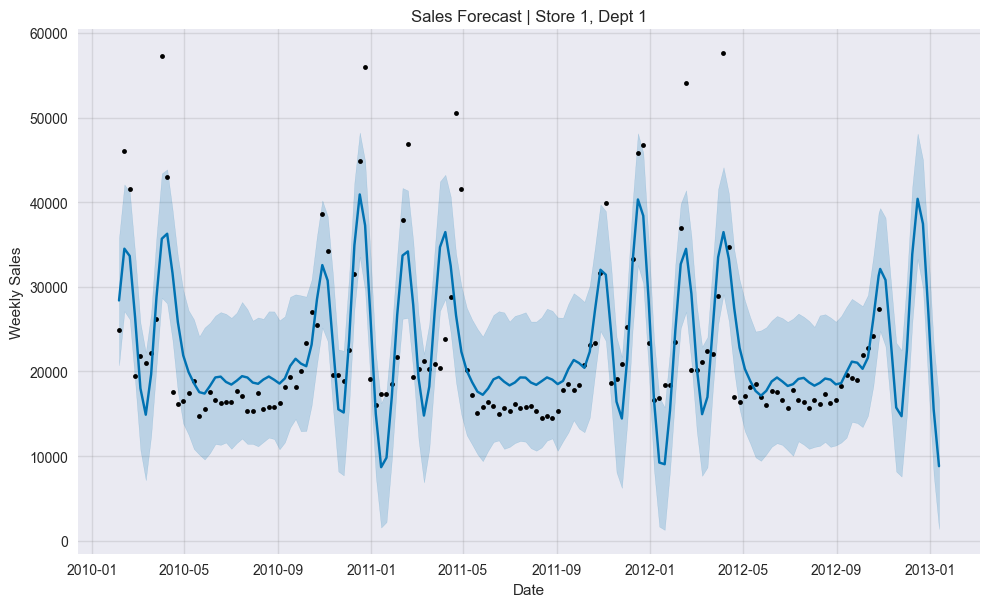

In [14]:
fig = final_model.plot(forecast)
plt.title(f"Sales Forecast | Store {STORE_ID}, Dept {DEPT_ID}")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.show()


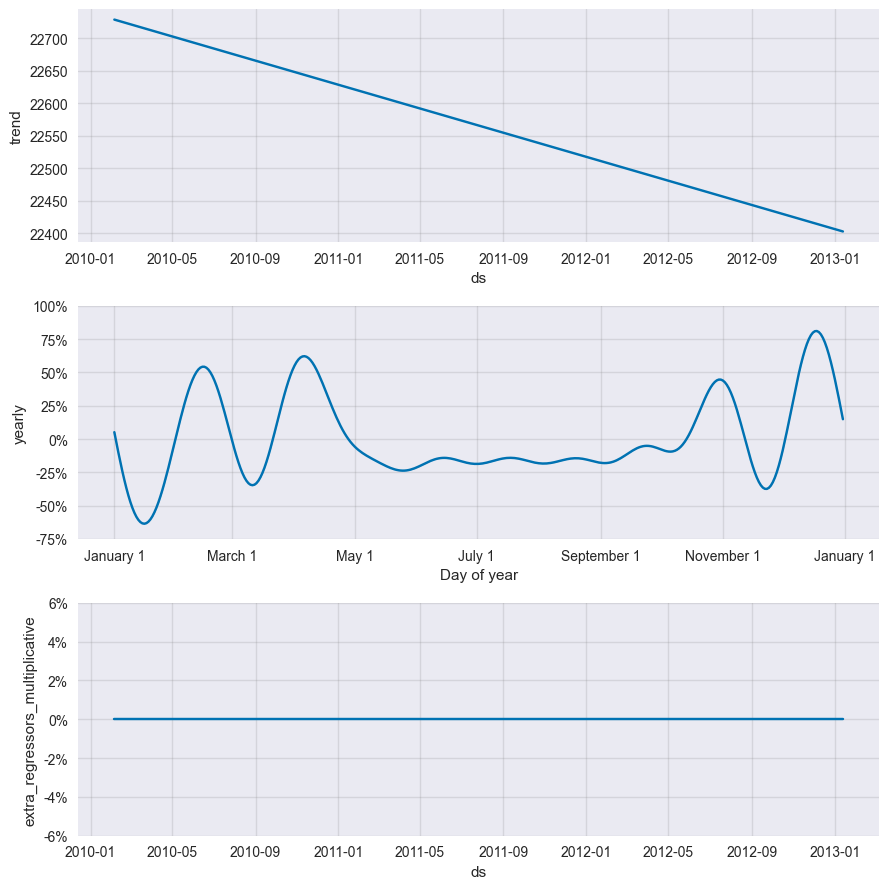

In [15]:
final_model.plot_components(forecast)
plt.show()


In [16]:
forecast_output = forecast[[
    "ds", "yhat", "yhat_lower", "yhat_upper"
]]

forecast_output.to_csv(
    "../data/processed/store1_dept1_forecast.csv",
    index=False
)
